## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [7]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('T:\HK I năm 3\Phân tích AI\Bài TH\hw\shopping_trends (1).csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [11]:
# TODO: check the dataset size with df.shape
df.shape


(3900, 19)

In [15]:
# TODO: drop the Customer ID column  
df = df.drop(columns=['Customer ID'])
df


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [16]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [17]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [18]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [19]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [21]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender']=='Female'] 

## **EDA**

### **Item Purchased**

In [23]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_df.value_counts().reset_index()
female_df.value_counts().reset_index()
df.value_counts().reset_index()


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,count
0,70,Male,Sweater,Clothing,35,Indiana,L,Beige,Fall,3.0,Yes,PayPal,2-Day Shipping,Yes,Yes,33,Venmo,Fortnightly,1
1,18,Female,Backpack,Accessories,94,Pennsylvania,L,Blue,Spring,3.5,No,Credit Card,Store Pickup,No,No,10,Bank Transfer,Every 3 Months,1
2,18,Female,Belt,Accessories,40,North Carolina,M,Lavender,Winter,4.6,No,Debit Card,Free Shipping,No,No,9,Venmo,Annually,1
3,18,Female,Boots,Footwear,71,Missouri,M,Teal,Spring,3.0,No,Cash,Standard,No,No,41,PayPal,Weekly,1
4,18,Female,Coat,Outerwear,28,Kentucky,S,Yellow,Winter,4.1,No,PayPal,Express,No,No,32,Bank Transfer,Fortnightly,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,18,Female,Shorts,Clothing,65,Alaska,XL,Brown,Spring,3.5,No,Bank Transfer,Express,No,No,5,Venmo,Weekly,1
3896,18,Female,Shorts,Clothing,25,Utah,M,Beige,Fall,3.0,No,Debit Card,Next Day Air,No,No,13,Venmo,Every 3 Months,1
3897,18,Female,Shirt,Clothing,57,Illinois,L,Olive,Winter,3.7,No,Venmo,2-Day Shipping,No,No,12,Cash,Fortnightly,1
3898,18,Female,Shirt,Clothing,50,Montana,M,Black,Winter,3.1,No,Cash,2-Day Shipping,No,No,18,Cash,Monthly,1


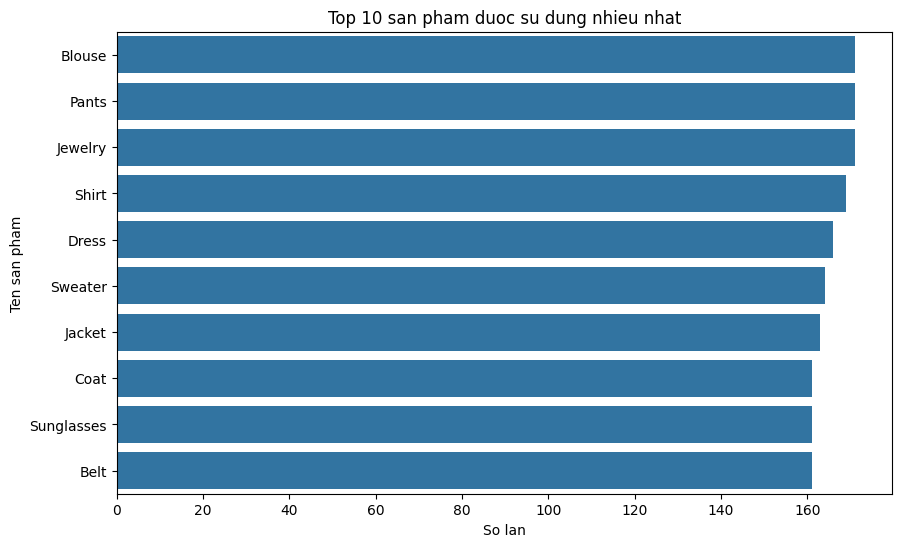

In [31]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top_10_items = df['Item Purchased'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top_10_items.values,
    y = top_10_items.index,
    legend=False
 )
plt.title('Top 10 san pham duoc su dung nhieu nhat')
plt.xlabel('So lan')
plt.ylabel('Ten san pham')
plt.show()

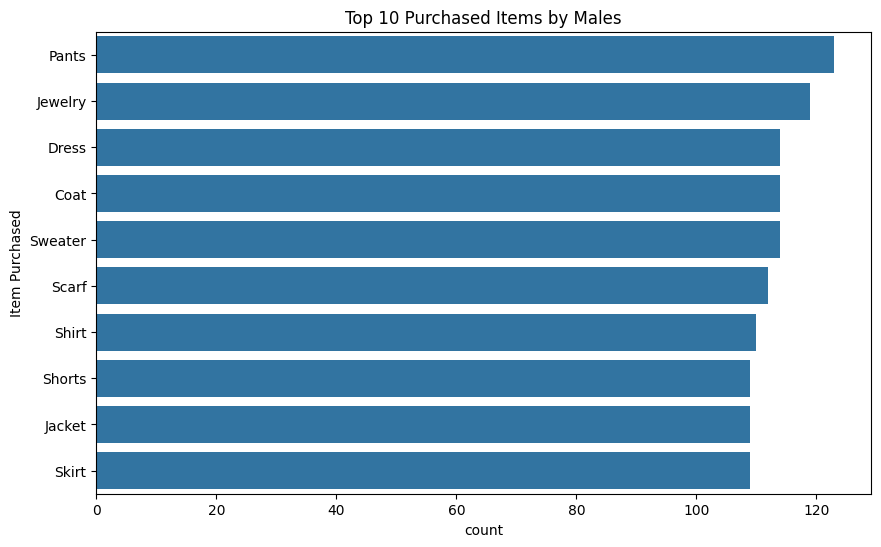

In [33]:
#TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top_10_items_males = male_df['Item Purchased'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top_10_items_males.values,
    y = top_10_items_males.index,
    legend=False,
    
    
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

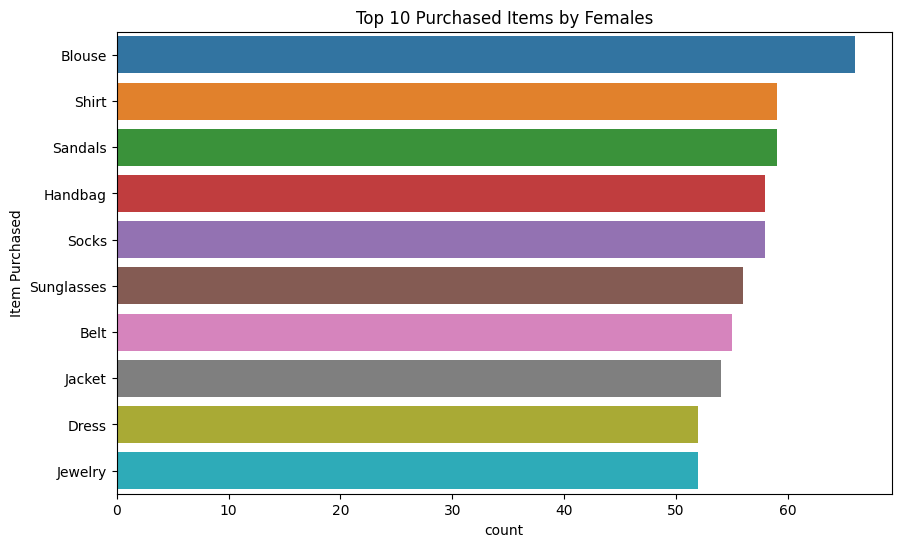

In [37]:
#TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top_item_f = female_df['Item Purchased'].value_counts().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [41]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts().reset_index()


,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [51]:
# TODO: count Size with value_counts() for male_df and female_df
print(male_df['Size'].value_counts().reset_index())
print('\n')
print(female_df['Size'].value_counts().reset_index())


  Size  count
0    M   1165
1    L    716
2    S    476
3   XL    295


  Size  count
0    M    590
1    L    337
2    S    187
3   XL    134


### **Category**

In [47]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [50]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
m_ctg = male_df['Category'].value_counts().reset_index()
print(m_ctg)
f_ctg = female_df['Category'].value_counts().reset_index()
print('\n')
print(f_ctg)


      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223


      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


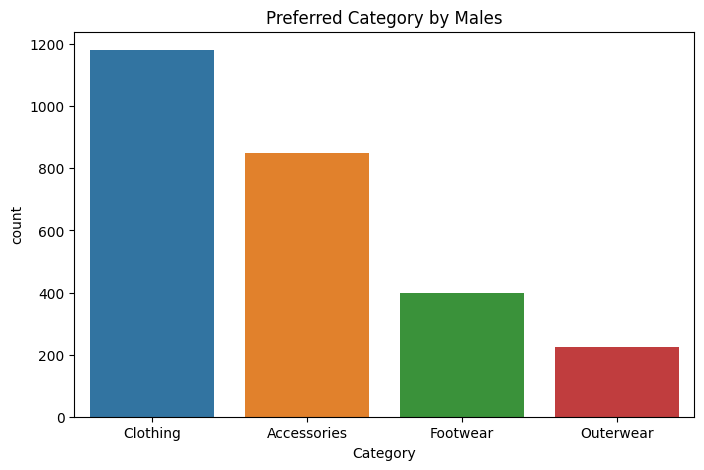

In [55]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data = m_ctg,
    x = 'Category',
    y = 'count',
    legend=False,
    hue='Category'


)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

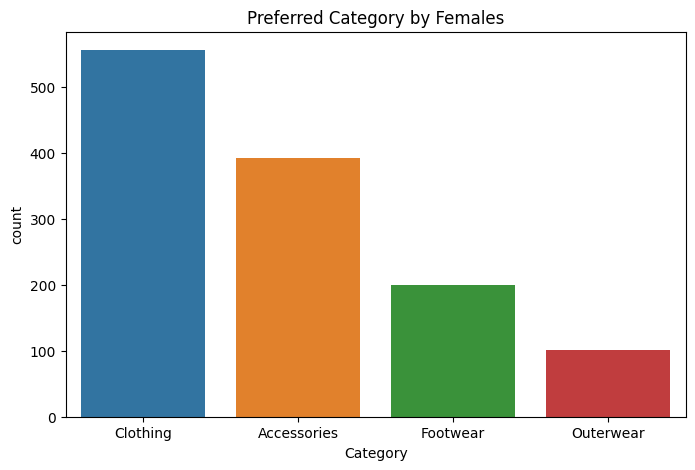

In [56]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data= f_ctg,
   x='Category',
   y='count',
   legend=False,
   hue='Category'
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

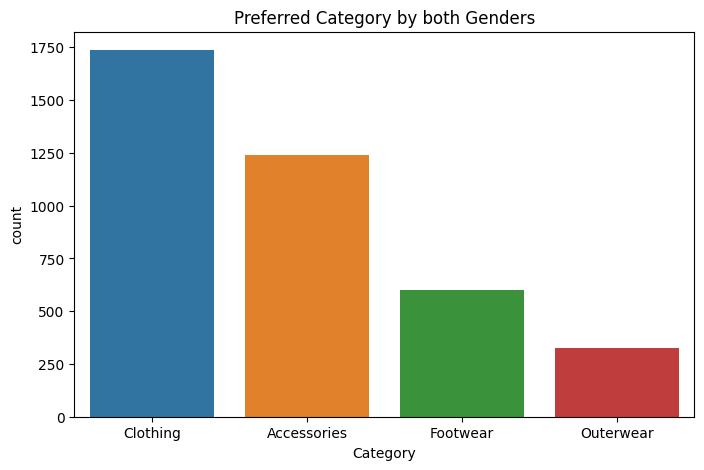

In [57]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [60]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()



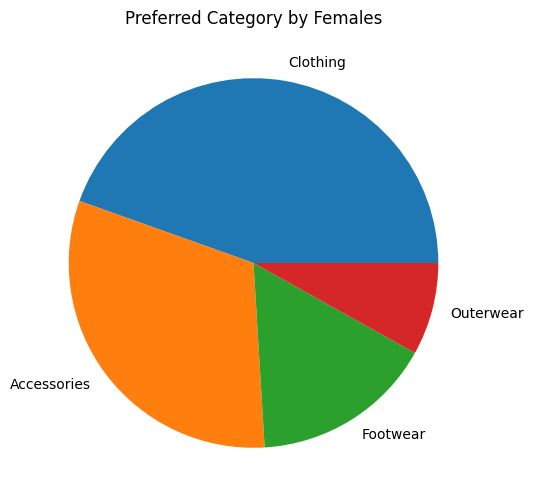

In [ ]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    x= waffle_data_f.values(),
    labels=waffle_data_f.keys()
   
)
plt.title("Preferred Category by Females")
plt.show()

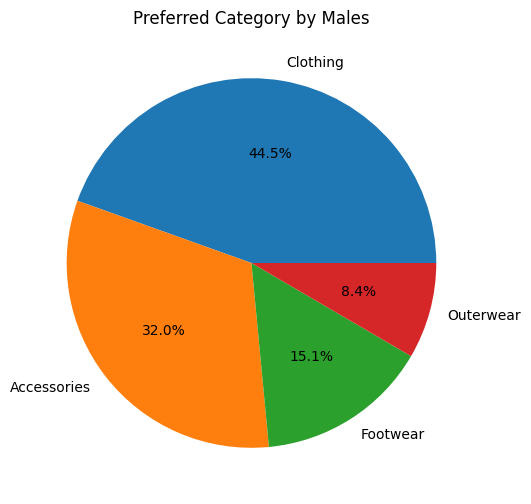

In [64]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [67]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

In [69]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

In [70]:
avg_cr_m,avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

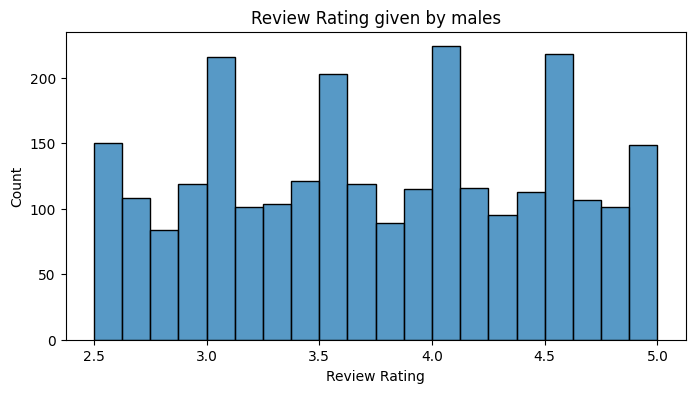

Text(0.5, 1.0, 'Review Rating given by females')

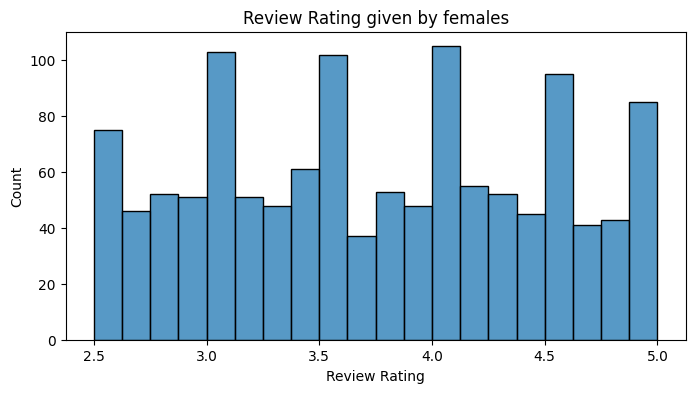

In [73]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(
    data = female_df,
    x = 'Review Rating',
    bins= 20
)
plt.title('Review Rating given by females')
# ?

In [75]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts().reset_index()


,Review Rating,count
0,3.7,61
1,3.4,59
2,2.7,55
3,2.9,55
4,4.2,52
5,3.9,52
6,4.0,52
7,3.0,49
8,3.3,49
9,4.1,48


### **Purchase Amount (USD)**

In [77]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

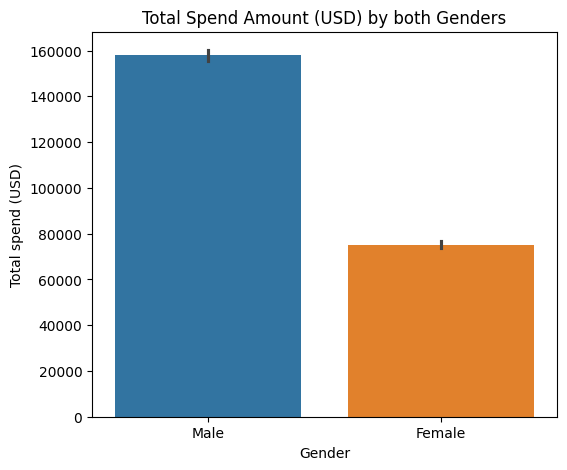

In [82]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    data = df,
    x = 'Gender',
    y = 'Purchase Amount (USD)',
    estimator='sum',
    hue = 'Gender',
    legend=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [83]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [84]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [89]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = df['Promo Code Used'].value_counts()
pcu_dict = dict(pcu)


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

<Axes: >

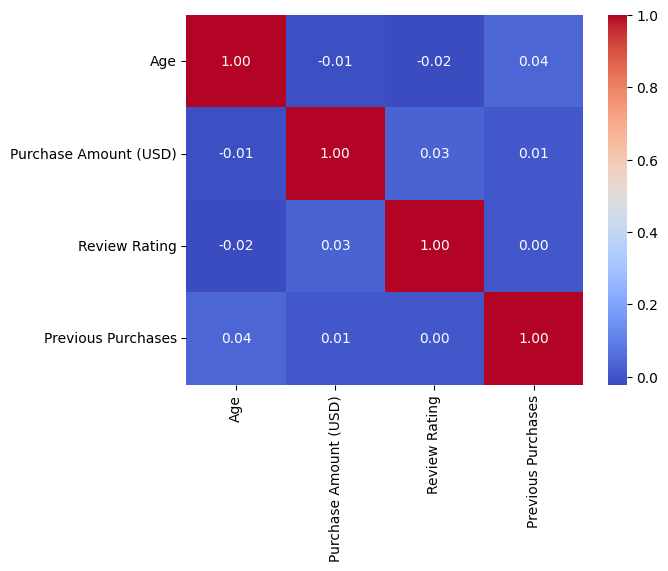

In [92]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
df.corr(numeric_only=True)
sns.heatmap(
    data = df.corr(numeric_only=True),
    annot=True,
    fmt = '.2f',
    cmap='coolwarm'
)



### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [ ]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [106]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [108]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins = 3,
    labels = ['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Sản phẩm phổ biến nhất ở cả nam và nữ là Clothing
- Khách nam có tổng chi tiêu cao hơn so với khách nữ
- Điểm trung bình Review Rating gần như đồng nhất giữa 2 giới
- 

Caveat: correlation is not causation.